# Testing Code for Optimizers

We will compare SOAP and AdamW

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from tqdm import tqdm

from experimental_optimizers.soap_mods import SOAP

Let's generate a simple 1D regression problem

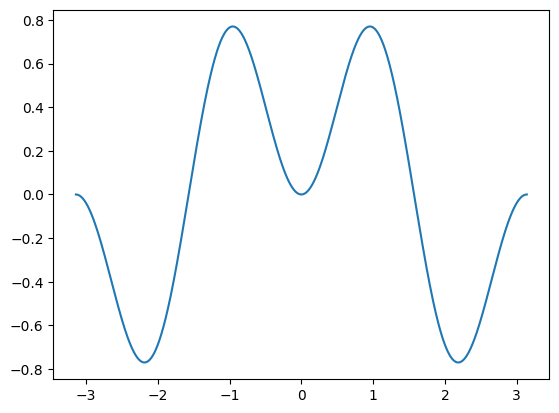

In [9]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)*np.sin(2*x)
plt.plot(x, y)
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Create the training and testing datasets, then create a training loop

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.reshape(-1, 1))
x_test = scaler.transform(x_test.reshape(-1, 1))

X_train = torch.from_numpy(x_train).float()
Y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(x_test).float()
Y_test = torch.from_numpy(y_test).float().unsqueeze(1)

Set up of the data loader, loss and optimizers

In [11]:
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
criterion = nn.MSELoss()

optimizer_configs = {
    "SOAP_no_projection":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=False, precondition_frequency=1),
    "SOAP_with_projection": lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=True, precondition_frequency=1),
    "AdamW":                lambda p: AdamW(p, lr=0.001, betas = (0.9, 0.999), weight_decay=0.01)
}


epochs = 200

In [12]:
for i, opt in enumerate(optimizer_configs):
    print(f"Training with {optimizer_configs[opt]}...")

Training with <function <lambda> at 0x7f8a116a6140>...
Training with <function <lambda> at 0x7f8a116a61f0>...
Training with <function <lambda> at 0x7f8a116a6400>...


In [13]:
def reset_weights(m, seed):
    if hasattr(m, 'reset_parameters'):
        torch.manual_seed(seed)
        torch.nn.init.xavier_normal_(m.weight)
        torch.nn.init.zeros_(m.bias)

## Training

In [15]:
results = {}

for i, opt_name in enumerate(optimizer_configs):
    model = LinearNN()
    # model.apply(lambda m: reset_weights(m, seed=42))
    opt_fun = optimizer_configs[opt_name]
    optimizer = opt_fun(model.parameters())
    print(f"Training with optimizer {optimizer.__class__.__name__}")
    loss_history = []
    
    pbar = tqdm(range(epochs), desc="Training",)
    for epoch in pbar:
        epoch_loss = 0.0
        for x_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(x_batch)

        epoch_loss /= len(X_train)
        loss_history.append(epoch_loss)  # save loss for this epoch
        if (epoch) % 10 == 0:
            pbar.set_postfix(mse=f"{epoch_loss:.6f}")
    results[opt_name] = {"model": model, "loss_history": loss_history}


Training with optimizer SOAP


Training: 100%|██████████| 200/200 [00:04<00:00, 42.87it/s, mse=0.000291]


Training with optimizer SOAP


Training: 100%|██████████| 200/200 [00:11<00:00, 17.83it/s, mse=0.000233]


Training with optimizer AdamW


Training: 100%|██████████| 200/200 [00:02<00:00, 70.05it/s, mse=0.000205]


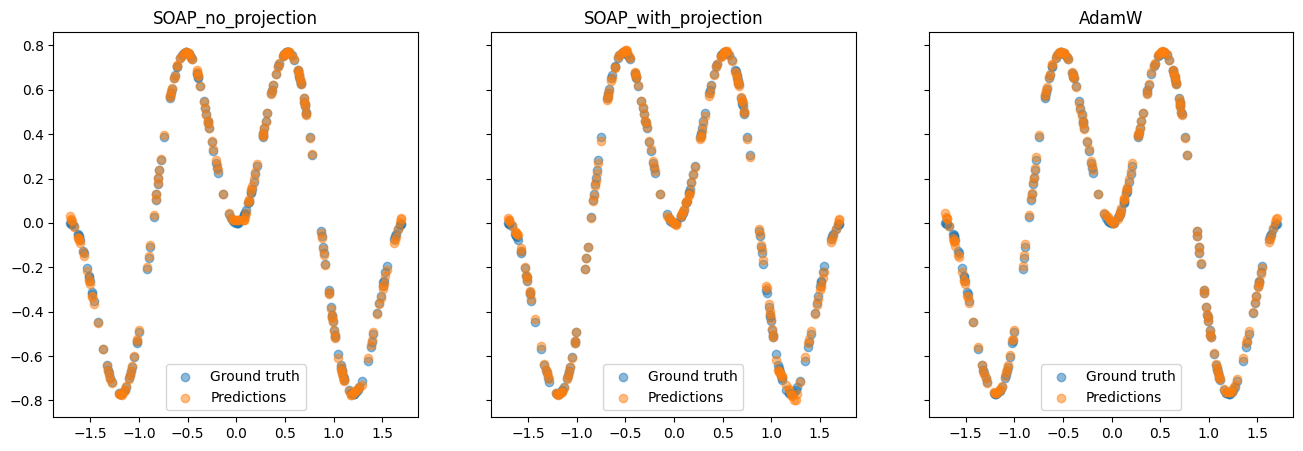

In [17]:
model.eval()

heigth = 5
width = len(optimizer_configs) * heigth + 1
fig, axs = plt.subplots(1, len(optimizer_configs), figsize=(width, heigth), sharey=True)

for i, opt_name in enumerate(optimizer_configs):
    with torch.no_grad():
        mod_to_plot = results[opt_name]["model"]
        preds = mod_to_plot(X_test).squeeze(1).numpy()

    axs[i].scatter(x_test, y_test, label="Ground truth", alpha=0.5)
    axs[i].scatter(x_test, preds, label="Predictions", alpha=0.5)
    axs[i].set_title(f"{opt_name}")
    axs[i].legend()

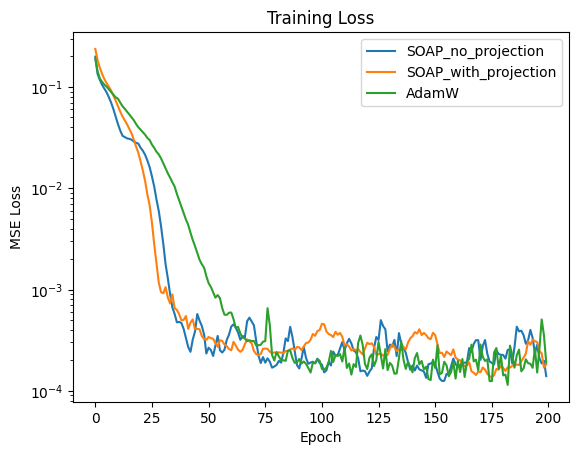

In [20]:
fig, ax = plt.subplots(1, 1)
for i, opt_name in enumerate(optimizer_configs):
    ax.plot(results[opt_name]["loss_history"], label=opt_name)
ax.set_title("Training Loss")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()